In [84]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

In [2]:
load_dotenv()

True

In [ ]:
model = ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [4]:
class Blogtate(TypedDict):
    title: str
    outline: str
    content: str

In [5]:
def create_outline(state: Blogtate) -> Blogtate:
    title = state['title']

    prompt = f"Generate a detailed outline for a blog on the topic - {title}"
    outline = model.invoke(prompt).content

    state['outline'] = outline

    return state

In [6]:
def create_blog(state: Blogtate) -> Blogtate:

    title = state['title']
    outline = state['outline']

    prompt = f"Write a detailed blog on the title - {title} using the following outiline {outline}"

    content = model.invoke(prompt).content

    state["content"] = content

    return state

In [7]:
graph = StateGraph(Blogtate)

graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)


graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)


workflow = graph.compile()

In [8]:
initial_state = {
    'title': "Rise of AI in Africa"
}

final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of AI in Africa', 'outline': 'Here is a detailed outline for a blog on the topic "Rise of AI in Africa":\n\n**I. Introduction**\n\n* Brief overview of the current state of Artificial Intelligence (AI) globally\n* Importance of AI in driving economic growth, innovation, and development\n* Thesis statement: Africa is experiencing a significant rise in AI adoption, with the potential to transform various sectors and drive economic growth\n\n**II. Current State of AI in Africa**\n\n* Overview of the current AI landscape in Africa, including the number of AI startups, investments, and research institutions\n* Discussion of the challenges facing AI adoption in Africa, such as limited infrastructure, lack of skilled talent, and regulatory frameworks\n* Examples of African countries that are leading the way in AI adoption, such as South Africa, Nigeria, and Kenya\n\n**III. Drivers of AI Adoption in Africa**\n\n* Discussion of the key drivers of AI adoption in Africa, including:

In [46]:
class EmployeeState(TypedDict):

    employee_name: str
    monthly_salary: int
    working_days: int
    completed_projects: int

    yearly_salary: int
    bonus_amount: int
    project_status: str
    summary: str

In [47]:
def calculate_yearly_salary(state: EmployeeState):
    yearly_salary = state["monthly_salary"] * 12
    return {
        "yearly_salary": yearly_salary
    }

In [48]:
def calculate_bonus(state: EmployeeState):
    bonus_amount = state['monthly_salary'] * 2
    return {
        "bonus_amount": bonus_amount
    }


In [49]:
def calculate_evaluation(state: EmployeeState):
    status = ""
    if state['completed_projects'] >= 5:
        status = "Excellent"
    else:
        status = "Average"

    return {
        "project_status": status
    }

In [50]:
def summary(state: EmployeeState):
    summary_text = f"Employee {state['employee_name']} has a yearly salary of {state['yearly_salary']} and bonus of {state['bonus_amount']}. Project status is {state['project_status']}"
    return {
        "summary": summary_text
    }

In [51]:
graph = StateGraph(EmployeeState)

graph.add_node("calculate_yearly_salary", calculate_yearly_salary)
graph.add_node("calculate_bonus", calculate_bonus)
graph.add_node("calculate_evaluation", calculate_evaluation)
graph.add_node("summary", summary)


graph.add_edge(START, 'calculate_yearly_salary')
graph.add_edge(START, 'calculate_bonus')
graph.add_edge(START, 'calculate_evaluation')

graph.add_edge("calculate_yearly_salary", "summary")
graph.add_edge("calculate_bonus", "summary")
graph.add_edge("calculate_evaluation", "summary")

graph.add_edge("summary", END)


workflow = graph.compile()

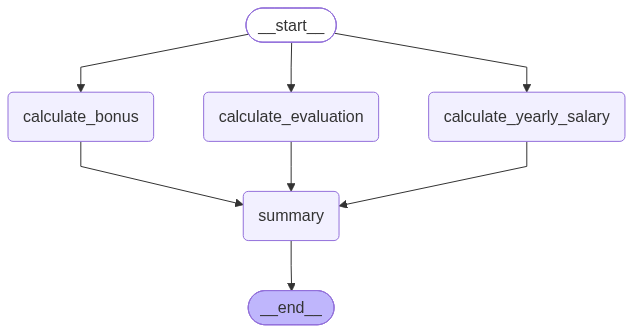

In [52]:
workflow

In [53]:
initial_state = {
    "employee_name": "John",
    "monthly_salary": 4000,
    "working_days": 26,
    "completed_projects": 7
}

result = workflow.invoke(initial_state)

print(result)

{'employee_name': 'John', 'monthly_salary': 4000, 'working_days': 26, 'completed_projects': 7, 'yearly_salary': 48000, 'bonus_amount': 8000, 'project_status': 'Excellent', 'summary': 'Employee John has a yearly salary of 48000 and bonus of 8000. Project status is Excellent'}


In [71]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description="Sentiment of the review")


class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "performance", "bug", "support", "other"] = Field(description="The category of issue mentioned in the review")
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description="the emotion tone expressed by the user")
    urgency: Literal["low", "medium", "high"] = Field(description="How urgent or critical the issue appears to be")
    

In [72]:
structured_model = model.with_structured_output(SentimentSchema)
diagnosis_model = model.with_structured_output(DiagnosisSchema)

In [73]:
class ReviewState(TypedDict):

    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [74]:
def find_sentiment(state: ReviewState):
    prompt = f"For the following review find out the sentiment \n {state["review"]}"
    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}


In [75]:
def positive_response(state: ReviewState):
    prompt = f"""
        Write a warm thank you message in response to this review:
        \n\n {state['review']}\n\n
Also, kindly ask the user to leave feedback on our website
    """
    response = model.invoke(prompt).content

    return {'response': response}

In [76]:
def run_diagnosis(state: ReviewState):
    prompt = f"""
        Diagnose this negative review:\n\n{state['review']}
        return issue type, tone, and urgency
    """
    response = diagnosis_model.invoke(prompt)

    return {'diagnosis': response.model_dump()}

In [77]:
def negative_response(state: ReviewState):
    diagnosis = state["diagnosis"]

    prompt = f"""
        You are a support assistant.
        The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
        Write an empathetic, helpful resolution message.
    """

    response = model.invoke(prompt).content

    return {"response": response}


In [78]:
def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:
    if state["sentiment"] == "positive":
        return "positive_response"
    else:
        return "run_diagnosis"

In [79]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)


graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge("positive_response", END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge("negative_response", END)


workflow = graph.compile( )

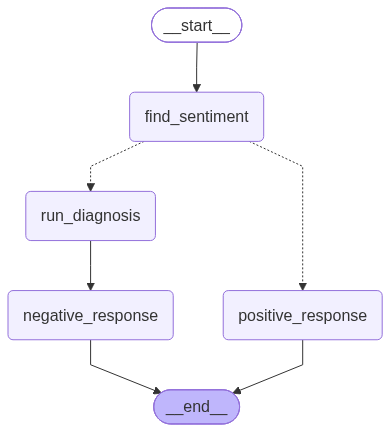

In [67]:
workflow

In [80]:
initial_state = {
     "review": "While the software has some useful features, my experience has been disappointing. It occasionally crashes, and some important functions are difficult to find. Performance can be slow with larger projects, and I encountered several bugs that affected my work. I hope future updates improve stability, usability, and overall reliability."
}

result = workflow.invoke(initial_state)

print(result)

{'review': 'While the software has some useful features, my experience has been disappointing. It occasionally crashes, and some important functions are difficult to find. Performance can be slow with larger projects, and I encountered several bugs that affected my work. I hope future updates improve stability, usability, and overall reliability.', 'sentiment': 'negative', 'diagnosis': {'issue_type': 'performance', 'tone': 'disappointed', 'urgency': 'medium'}, 'response': "I'm so sorry to hear that you're experiencing a performance issue, and I can sense your disappointment. I'm here to help and want to assure you that I'm committed to resolving this for you.\n\nI understand that this issue is causing you inconvenience, and I appreciate you bringing it to my attention. Since you've marked the urgency as medium, I'll make sure to prioritize it accordingly and work on a solution as soon as possible.\n\nTo better understand the issue, could you please provide me with more details about th

In [81]:
generator_llm = ChatGroq(model="llama-3.3-70b-versatile")
evaluator_llm = ChatGroq(model="llama-3.3-70b-versatile")
optimizer_llm = ChatGroq(model="llama-3.3-70b-versatile")

In [82]:
class PostEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result")
    feedback: str = Field(..., description="feedback for the facebook post.")

In [83]:
structured_evaluator_llm = evaluator_llm.with_structured_output(PostEvaluation)

In [85]:
class PostState(TypedDict):

    topic: str
    post: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    post_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [86]:
from langchain_core.messages import SystemMessage, HumanMessage

In [87]:
def generate_post(state: PostState):
    message = [
        SystemMessage(content="You are a funny and clever Facebook influencer"),
        HumanMessage(content=f"""
            Write a short, original, and hilarious Facebook post on the topic: "{state['topic']}"

            Rules:
            - Do NOT use question-answer format.
            - Max 500 characters.
            - Use observational humor, irony, sarcasm, or cultural references.
            - Think in meme logic, punchlines, or relatable takes.
            - Use simple, day to day english
        """)
    ]

    response = generator_llm.invoke(message).content

    return {'post': response, 'post_history': [response]}

In [88]:
def evaluate_post(state: PostState):
    message = [
    SystemMessage(
        content="""
    You are a ruthless, no-laugh-given Facebook critic.
    """
        ),
        HumanMessage(
            content=f"""
    Evaluate the following Facebook post:

    Post :
    {state['post']}

Use the criteria bellow to evaluate the post
1. Originality -is this fresh, or have you seen it a hundred times before ?
2. Humor - did it genuinely make you smile, laugh, or chuckle?
3. Punchlines - is it short, sharp, and scroll-stopping ?
4. Virality potential - would people share, react or comment on it?
5. Format - is it a well-formated facebook post (not a setup-punchline joke, not a Q&A joke, and under 500 characters) ?

Auto-reject if:
- It's written in question answer format (e.g. "why did ..." or "what happens when ...")
- It exceeds 500 characters
- It reads like a traditional setup-punchline joke
- Don't end with generic, throwaway, or deflating lines that weaken the humor

### Respond ONLY in structured format
- evaluation: "approved" or "needs_improvement"
- feedback: one paragraph explaining the strength and weakness
    """
        ),
    ]

    response = structured_evaluator_llm.invoke(message)

    return {'evaluation': response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}


In [91]:
def optimize_post(state: PostState):
    messages = [
        SystemMessage(content="You punch up posts for virality and humor based on given feedback."),
        HumanMessage(content=f"""
            Improve the Facebook post on this feedback:
            "{state['feedback']}"

            Topic: "{state['topic']}"
            Original post: 
            {state['post']}
            Re-write it as a short, viral-worthy Facebook post. Avoid Q&A style and stay under 500 characters
        """)
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'post': response, 'iteration': iteration, 'post_history': [response]}

In [89]:
def route_evaluation(state: PostState):

    if state['evaluation'] == "approved" or state['iteration'] >= state['max_iteration']:
        return "approved"
    else:
        return "needs_improvement"

In [93]:
graph = StateGraph(PostState)

graph.add_node("generate", generate_post)
graph.add_node("evaluate", evaluate_post)
graph.add_node("optimize", optimize_post)


graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', route_evaluation, {"approved": END, "needs_improvement": 'optimize'})
graph.add_edge('optimize', "evaluate")

workflow = graph.compile()


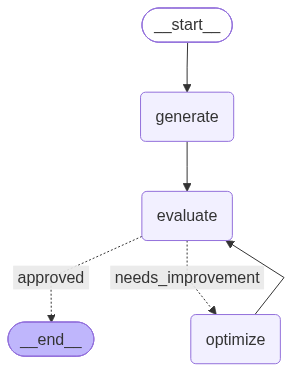

In [94]:
workflow

In [95]:
initial_state = {
    'topic': "agentic AI",
    'iteration': 1,
    'max_iteration': 5
}

result = workflow.invoke(initial_state)

print(result)

{'topic': 'agentic AI', 'post': '"just taught my agentic AI to make coffee and now it\'s unionizing the kitchen appliances"', 'evaluation': 'approved', 'feedback': "This post is a breath of fresh air, offering a unique blend of technology and humor. The idea of an agentic AI unionizing kitchen appliances is original and clever, making it scroll-stopping and potentially viral. The post is well-formatted, concise, and under 500 characters, which adds to its strength. The punchline is short and sharp, and the use of the word 'unionizing' adds a layer of depth to the humor. Overall, this post has a high potential for virality and is likely to make readers smile or chuckle.", 'iteration': 1, 'max_iteration': 5, 'post_history': ['"just taught my agentic AI to make coffee and now it\'s unionizing the kitchen appliances"'], 'feedback_history': ["This post is a breath of fresh air, offering a unique blend of technology and humor. The idea of an agentic AI unionizing kitchen appliances is origin